In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings("ignore") #It has been used to hide the warnings, if any.

sns.set(style = "whitegrid")

In [ ]:
df = pd.read_csv("fraud_detection_dataset.csv")

In [ ]:
df.sample(10)
# How does our data look like

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
187527,13,CASH_OUT,124315.77,C1222776036,0.00,0.00,C881825909,328539.37,0.00,0,0
4417385,322,PAYMENT,44778.26,C1953238704,0.00,0.00,M582909059,0.00,0.00,0,0
1355499,138,PAYMENT,4088.20,C2067900029,0.00,0.00,M1073894251,0.00,0.00,0,0
4945232,351,CASH_IN,122131.44,C279306625,9039.00,131170.44,C2134459600,424112.87,301981.43,0,0
6181721,566,CASH_IN,88042.98,C706030233,506133.00,594175.98,C2078368393,0.00,0.00,0,0
1029384,48,PAYMENT,2633.34,C673053823,32930.00,30296.66,M59093336,0.00,0.00,0,0
3281796,251,PAYMENT,40178.36,C1833427669,479.00,0.00,M1421581377,0.00,0.00,0,0
2981188,231,PAYMENT,25513.02,C1915062677,54680.00,29166.98,M2127794652,0.00,0.00,0,0
2053480,181,PAYMENT,917.84,C213425946,402952.83,402034.99,M1360825678,0.00,0.00,0,0
635032,35,PAYMENT,6558.72,C1753715532,0.00,0.00,M691531665,0.00,0.00,0,0


In [ ]:
df.info()
#What are data types of the columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df["isFraud"].value_counts() 

#output shows the data is extremely imbalanced

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
df.isnull().sum() 

#shows column wise count of null values

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [ ]:
df.shape 

#shape is 6.3Mn rows and 11 columns

(6362620, 11)

In [ ]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)

# calculates percentage of fraudulent transactions
# value_counts().loc[1] gives the count of records where isFraud = 1
# df.shape[0] gives the total number of transactions
# output is 0.13% of transactions are fraudulent

np.float64(0.13)

In [ ]:
df.duplicated().sum()

# Checks for any duplicate rows in our data

np.int64(0)

Text(0, 0.5, 'Count of Transactions')

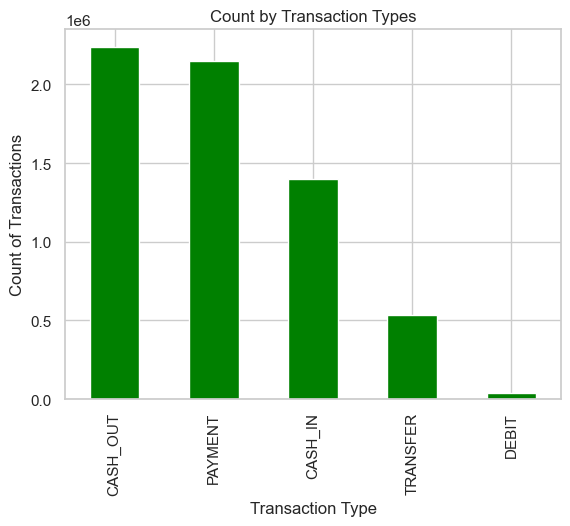

In [ ]:
t_type_chart = df["type"].value_counts().plot(kind = "bar", title = "Count by Transaction Types", color = "green")
t_type_chart.set_xlabel("Transaction Type")
t_type_chart.set_ylabel ("Count of Transactions")

#This is EDA (univariate analysis)

Text(0, 0.5, 'Fraud Rate')

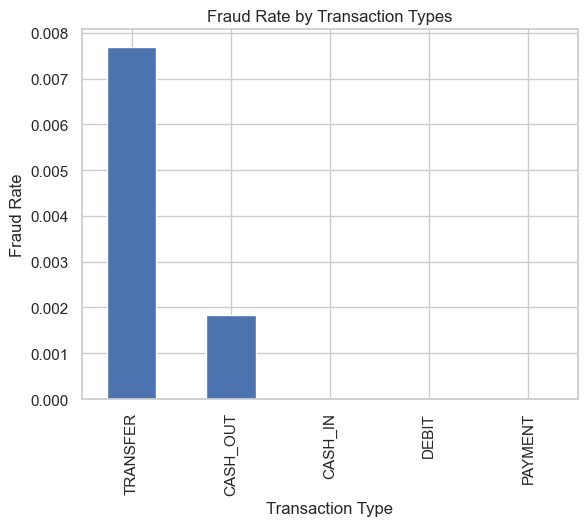

In [ ]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending = False)
fraud_by_type_chart = fraud_by_type.plot(kind = "bar", title = "Fraud Rate by Transaction Types")
fraud_by_type_chart.set_xlabel("Transaction Type")
fraud_by_type_chart.set_ylabel("Fraud Rate")

In [ ]:
df["amount"].describe().astype(int)

#gives mathematical summary of Amount column

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

Text(0.5, 0, 'Log(Amount +1)')

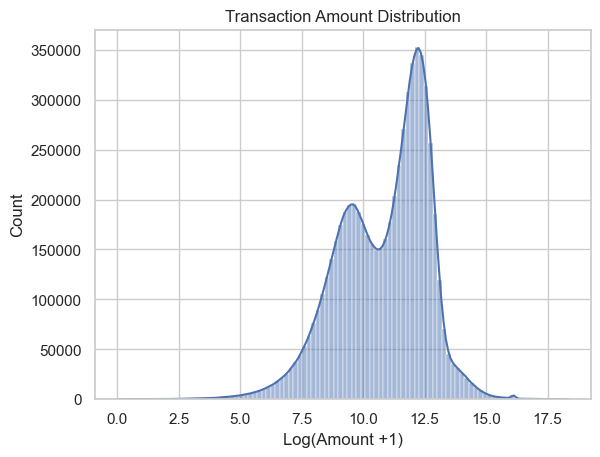

In [ ]:
amount_chart = sns.histplot(np.log1p(df["amount"]), bins = 100, kde = True)
amount_chart.set_title("Transaction Amount Distribution")
amount_chart.set_xlabel("Log(Amount +1)")

Text(0.5, 1.0, 'Spread of amounts across Fraud and Genuine Transactions (<50k)')

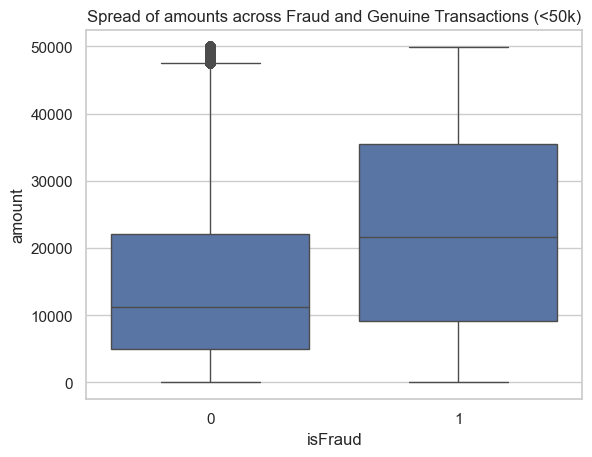

In [ ]:
filtered_df = df[df["amount"] < 50000]

boxplot_graph = sns.boxplot(x = filtered_df["isFraud"], y=filtered_df["amount"])
boxplot_graph.set_title("Spread of amounts across Fraud and Genuine Transactions (<50k)")

In [ ]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [ ]:
(df["balanceDiffOrig"] <0).sum()

np.int64(1399253)

In [ ]:
(df["balanceDiffDest"] <0).sum()

np.int64(1238864)

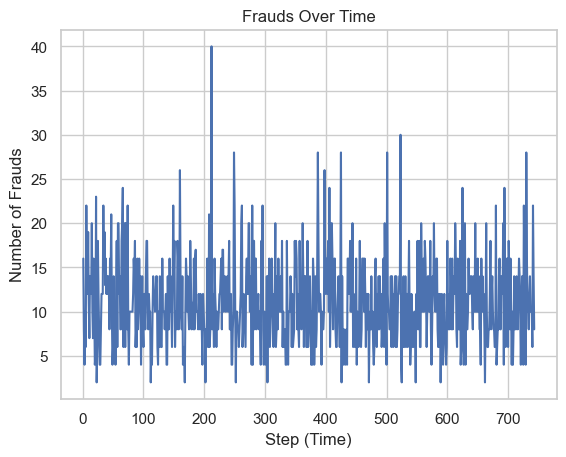

In [ ]:
frauds_per_step = df[df["isFraud"]==1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)

#Output shows its  not time dependent

In [ ]:
df.drop("step", axis = 1, inplace = True)

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [ ]:
top_senders = df["nameOrig"].value_counts().sort_values(ascending = False).head(10)
top_senders

nameOrig
C1902386530    3
C2098525306    3
C363736674     3
C1530544995    3
C1065307291    3
C2051359467    3
C1832548028    3
C400299098     3
C1976208114    3
C1999539787    3
Name: count, dtype: int64

In [ ]:
top_receivers = df["nameDest"].value_counts().head(10).sort_values(ascending = False).head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [ ]:
fraud_users = df[df["isFraud"]==1]["nameOrig"].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

In [ ]:
fraud_types = df[df["type"].isin(["CASH_OUT", "TRANSFER"])]
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

Text(0.5, 1.0, 'Fraud Distribution in Transfer & Cash Out')

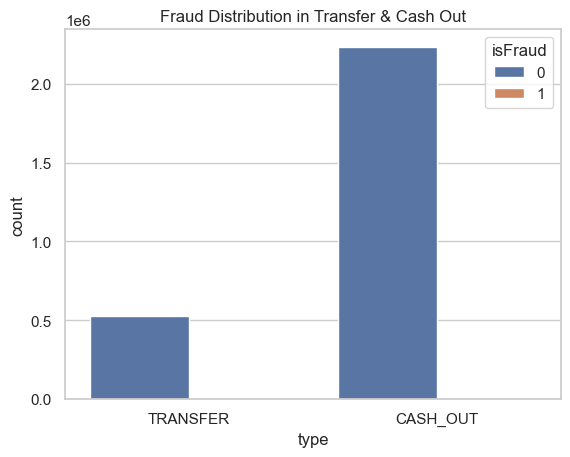

In [ ]:
sns.countplot(data = fraud_types, x="type", hue= "isFraud")
plt.title("Fraud Distribution in Transfer & Cash Out")

Text(0.5, 1.0, 'Correlation Matrix')

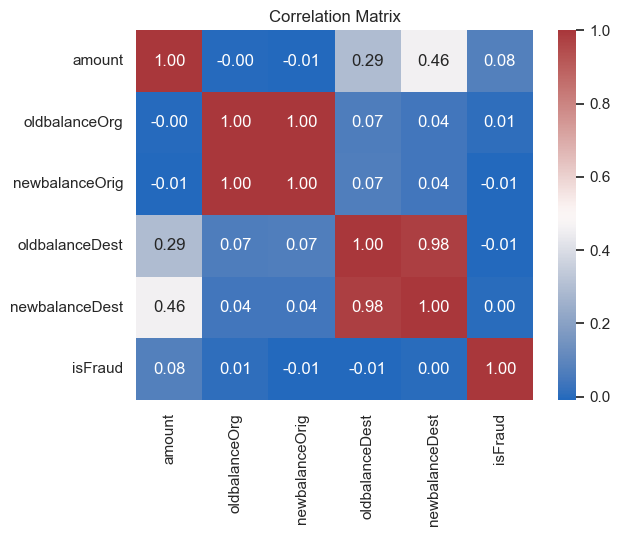

In [ ]:
correlation = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

sns.heatmap(correlation, annot = True, cmap = "vlag", fmt = ".2f")
plt.title("Correlation Matrix")

In [ ]:
zero_after_transfer = df [(df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0) & (df["type"].isin(["TRANSFER", "CASH_OUT"]))]
len(zero_after_transfer)

1188074

In [ ]:
zero_after_transfer.sample(10)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
4965987,TRANSFER,964828.84,C579139861,11774.00,0.0,C994378031,248797.56,1213626.40,0,0,11774.00,964828.84
67415,CASH_OUT,132742.51,C914583419,31582.91,0.0,C678279746,826438.71,1233914.03,0,0,31582.91,407475.32
5186173,TRANSFER,1238254.37,C939314687,147557.19,0.0,C191649712,2486830.81,3725085.18,0,0,147557.19,1238254.37
1891434,TRANSFER,362758.60,C495455817,38008.00,0.0,C926635314,0.00,362758.60,0,0,38008.00,362758.60
3526629,CASH_OUT,117707.40,C1502879501,76.00,0.0,C439863039,84504.01,202211.41,0,0,76.00,117707.40
4686826,CASH_OUT,154472.33,C928919830,32346.00,0.0,C1909693973,38870.03,193342.36,0,0,32346.00,154472.33
5492451,TRANSFER,749861.41,C1757799052,10173.00,0.0,C549833615,992194.12,1742055.53,0,0,10173.00,749861.41
4920723,CASH_OUT,244705.10,C207176434,36906.00,0.0,C1478429970,0.00,244705.10,0,0,36906.00,244705.10
2618234,CASH_OUT,43252.06,C34581493,673.00,0.0,C1710077801,0.00,43252.06,0,0,673.00,43252.06
4777002,TRANSFER,180666.15,C1095073914,8991.00,0.0,C1344655636,468846.23,649512.38,0,0,8991.00,180666.15


In [ ]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [ ]:
df.head(10)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0,9839.64,0.00
1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0,1864.28,0.00
2,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0,181.00,-21182.00
4,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0,11668.14,0.00
5,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0,7817.71,0.00
6,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0,7107.77,0.00
7,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0,7861.64,0.00
8,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0,2671.00,0.00
9,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0,5337.77,-1549.21


In [ ]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [ ]:
categorical = ["type"]
numerical = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [ ]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [ ]:
X.dtypes

type                object
amount             float64
oldbalanceOrg      float64
newbalanceOrig     float64
oldbalanceDest     float64
newbalanceDest     float64
balanceDiffOrig    float64
balanceDiffDest    float64
dtype: object

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

In [ ]:
transformer = ColumnTransformer(
                transformers = [ 
                    ("scaling", StandardScaler(), numerical),
                    ("encoding", OneHotEncoder(drop = "first"), categorical)
                 ], remainder = "drop")

In [ ]:
pipeline = Pipeline([
            ("prep", transformer),
            ("clf", LogisticRegression(class_weight = "balanced", max_iter = 1000))
        ])
    

In [ ]:
pipeline.fit(X_train, y_train) 
#Training our model

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('encoding', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270875
           1       0.02      0.94      0.05      1649

    accuracy                           0.95   1272524
   macro avg       0.51      0.94      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [ ]:
confusion_matrix(y_test, y_pred)

array([[1206839,   64036],
       [    101,    1548]])

In [ ]:
pipeline.score(X_test, y_test)*100

94.959859303243

In [ ]:
import joblib

joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']